라이브러리 세팅

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical


이미지 데이터 다운로드 및 스케일링

In [2]:
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps.zip \
    -O ./rps.zip

!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps-test-set.zip \
    -O ./rps-test-set.zip

local_zip = './rps.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('./')
zip_ref.close()

TRAINING_DIR = "./rps/"
training_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

local_zip = './rps-test-set.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('./')
zip_ref.close()

VALIDATION_DIR = "./rps-test-set/"
validation_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = training_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size = (150, 150),
    class_mode = 'categorical'
)
validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(150,150),
    class_mode='categorical'
)

--2025-03-12 05:53:56--  https://storage.googleapis.com/learning-datasets/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.197.207, 74.125.135.207, 142.250.107.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.197.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘./rps.zip’

./rps.zip           100%[===================>] 191.38M  99.3MB/s    in 1.9s    

2025-03-12 05:53:58 (99.3 MB/s) - ‘./rps.zip’ saved [200682221/200682221]

--2025-03-12 05:53:58--  https://storage.googleapis.com/learning-datasets/rps-test-set.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.197.207, 74.125.135.207, 142.250.107.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.197.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29516758 (28M) [application/zip]
Saving to: ‘./rps-test-set.zip’

./rps-test-set.z

모델 구현

In [3]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu',
                           input_shape = (150, 150, 3)),           # 첫번째 합성곱 층, 입력 크기는 원하는 이미지 (150x150, 3채널(컬러)과 일치 해야함)
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'),       # 두번째 합성곱 층
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu'),      # 세번째 합성곱 층
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu'),               # 네번째 합성곱 층
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),    #밀집층에 전달하기 위해서 펼치는 작업

    tf.keras.layers.Dense(512, activation = 'relu'),   #512개의 뉴런을 가진 은닉층
    tf.keras.layers.Dense(3, activation = 'softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


모델 컴파일

In [4]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'rmsprop',
              metrics = ['accuracy'])  # A이냐 B이냐 일때는 binary cross entropy 손실함수 사용 했으나 이번에는 2개 이상이므로 categorical 사용

모델 훈련

In [5]:
model.fit(train_generator,
          epochs = 25,
          validation_data = validation_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 322ms/step - accuracy: 0.3720 - loss: 1.1572 - val_accuracy: 0.6183 - val_loss: 0.9022
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 272ms/step - accuracy: 0.5462 - loss: 0.9236 - val_accuracy: 0.8602 - val_loss: 0.3580
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step - accuracy: 0.7471 - loss: 0.5933 - val_accuracy: 0.9624 - val_loss: 0.1275
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 257ms/step - accuracy: 0.8570 - loss: 0.3692 - val_accuracy: 0.8925 - val_loss: 0.2495
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 265ms/step - accuracy: 0.8975 - loss: 0.2823 - val_accuracy: 0.9355 - val_loss: 0.1474
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 264ms/step - accuracy: 0.9251 - loss: 0.2273 - val_accuracy: 0.9651 - val_loss: 0.1019
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.9409 - loss: 0.1629 - val_accuracy: 0.9382 - val_loss: 0.1720
Epoch 8/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 259ms/step - accuracy: 0.9594 - loss: 0.1262 - val_accu

모델 예측

Saving rsp_img1.png to rsp_img1.png
Saving rsp_img2.png to rsp_img2.png
Saving rsp_img3.png to rsp_img3.png


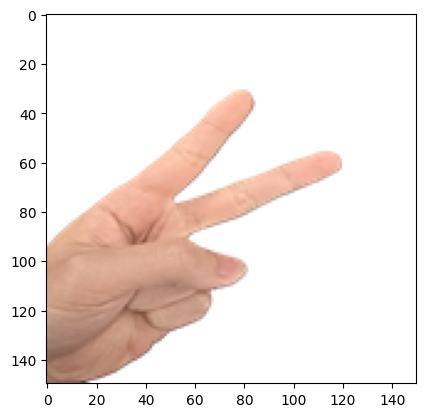

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
/content/rsp_img1.png는가위입니다.


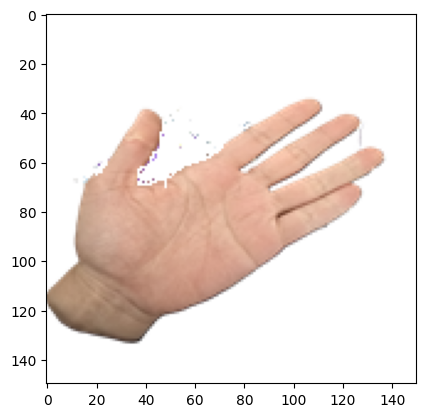

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
/content/rsp_img2.png는보입니다.


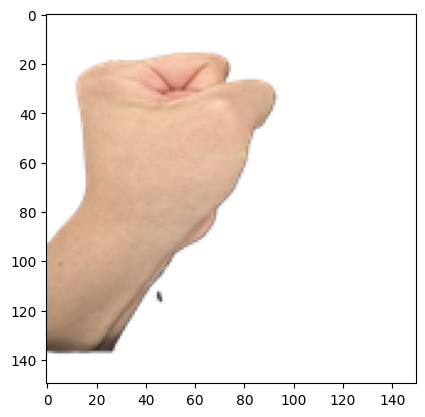

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
/content/rsp_img3.png는바위입니다.


In [9]:
import sys
if 'google.colab' in sys.modules:
  from google.colab import files
  uploaded = files.upload()
  sample_images = ['/content/' + fn for fn in uploaded.keys()]

  if len(uploaded) < 1:
    import gdown
    base_url = 'https://github.com/rickiepark/aiml4coders/raw/main/ch03/'
    for i in range(1,4):
      gdown.download(base_url + 'rsp_image_{}.jpg'.format(i))
    smaple_images = ['/content/rsp_image_{}.jpg'.format(i) for i in range(1,4)]
    rsp_name = ['보', '바위', '가위']
else:
  smaple_images = ['rsp_image_{}.jpg'.format(i) for i in range(1,4)]

rsp_name = ['보', '바위', '가위']
for fn in sample_images:
  plt.imshow(mpimg.imread(fn))
  plt.show()
  img = tf.keras.utils.load_img(fn, target_size = (150, 150))
  x = tf.keras.utils.img_to_array(img)
  x = np.expand_dims(x, axis = 0)

  classes = model.predict(x)

  idx = np.argmax(classes[0])
  print(fn+"는{}입니다.".format(rsp_name[idx]))